purpose: 
train a very simple image classifier before using tensorflow which essentially answers, can a simple model learn anything from the gathered images

method:
1. load the split CSV files train, val, test, csv's
2. open each of the processed images
3. convert the images into numpy arrays
4. normalize pixel values
5. flatten images for scikit-learn
6. convert text labels into numbers
7. train logistic regression
8. evaluate on validation set

In [1]:
from pathlib import Path
from PIL import Image ## used for opening image files
import numpy as np ## used for numerical arrays since the images need to become numbers beofre the model can learn from them 
import pandas as pd ## used to load csv files 
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

train_df.head()

,original_path,processed_path,label
0,..\data\raw\inflammatory_acne\inflam_021.jpg,..\data\processed\inflammatory_acne\inflammato...,inflammatory_acne
1,..\data\raw\comedonal_closed\come_048.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed
2,..\data\raw\comedonal_open\comeo_008.png,..\data\processed\comedonal_open\comedonal_ope...,comedonal_open
3,..\data\raw\acne_scars\scar_016.png,..\data\processed\acne_scars\acne_scars_0016.jpg,acne_scars
4,..\data\raw\acne_scars\scar_041.png,..\data\processed\acne_scars\acne_scars_0041.jpg,acne_scars


In [3]:
## takes a dataframe and returns x and y which represent image data and labels respectively
## x and y are commonly inputs/features and target labels for this project x and y are acne images and acne class names 
def load_images(df):
    ## create empty list to store all image and labels 
    images = []
    labels = []
    ## note each row contains one image path and one label 
    for _, row in df.iterrows():
        img = Image.open(row["processed_path"]).convert("RGB") ## convert rgb so that every image has 3 colour channels 
        img_array = np.array(img) / 255.0 ## convert the image into numbers for normalization
        ## note pixels are usually 0 - 255 but dividing by 255 makes it 0 to 1
        ## where 0 = black, 1 = full brightness and anything between like 0.5 is 
        ## middle brightness 
        ## need this normalization so that the model can train better since they
        ## train better when input values are small and consaistent
        ## this normalization effectively reduces the values from 0 to 255 to 0 to 1
        images.append(img_array) ## store the image array
        labels.append(row["label"]) ## store class name

    return np.array(images), np.array(labels) ## turns the python list in numpy arrays which models can work with

In [4]:
X_train, Y_train = load_images(train_df) ## training images, training labels
X_val, Y_val = load_images(val_df) ## validation images, validation labels
X_test, Y_test = load_images(test_df) ## test images, test labels 

print("X_train shape:", X_train.shape)
print("y_train shape:", Y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", Y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", Y_test.shape)



X_train shape: (177, 224, 224, 3)
y_train shape: (177,)
X_val shape: (38, 224, 224, 3)
y_val shape: (38,)
X_test shape: (38, 224, 224, 3)
y_test shape: (38,)


X_train shape: (95, 224, 224, 3) represents 95 training images, 224 image height, 224 image width, 3 colour changels (rgb)
y_train shape: (95,) represents 95 labels, one for each training image



Now we need to flatten the images since our shape right now is a 3d image shape 
(224 x 224 x 3)

since we are using utlizing logistic regression from scikit learn it expects data like a table where its rows and column

logistic regression: 
machine learning algorithm used to predict which category something belonags to, even though the name says regression in essence its a classification algorithm 

instead of prediciting a continuous number it predicts the probability that something belongs to a class

usually outputs a probability between 0 and 1 and then uses a threshold value to make a final decision 

In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1) ## shape[0] =  number of images this case 95, -1 
## means find the size automatically, size = 224 x 224 x 3 so reshape = (95, (224x224x3) = 150528)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened train shape:", X_train_flat.shape)

Flattened train shape: (177, 150528)


since the labels are currently in text format:

comedonal_closed
comedonal_open
acne_excoriee
inflammatory_acne
acne_scars

we need to change them into numbers so that ml models can use them

in this case we use labelencoder from sklearn which essentially gives each label a number

acne_excoriee       → 0
acne_scars          → 1
comedonal_closed    → 2
comedonal_open      → 3
inflammatory_acne   → 4

based on alphabetical order

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(Y_train) ## fit_transform on training only since fit 
## learns the label mapping, and transform, converts the label to numbers 
## validation/test only use transform since the label mapping should be learned from training labels and resused consistently 
## ie, acne_scars should be always map to the same number across train, validation, and test 
y_val_encoded = label_encoder.transform(Y_val) 
y_test_encoded = label_encoder.transform(Y_test)

print(label_encoder.classes_)
print(Y_train[:5])
print(y_train_encoded[:5])

['acne_excoriee' 'acne_scars' 'comedonal_closed' 'comedonal_open'
 'inflammatory_acne']
['inflammatory_acne' 'comedonal_closed' 'comedonal_open' 'acne_scars'
 'acne_scars']
[4 2 3 1 1]


create and train baseline model

will use logistic regression, as mentioned it will be used for classification and here specifically it will try to learn patterns that separate the acne classes based on pixel values 

might not be ideal for images, but simple and useful as a baseline

In [7]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000, ## model learns by improving itself over multiple iterations, since there are 150k+ features, give it more iterations
    class_weight="balanced", ## normalizes the priority, since right now the dataset is imbalanced, without it the model may focus too much on bigger classes
    random_state=42
)

baseline_model.fit(X_train_flat, y_train_encoded) ## training step, shows the model image pixels to correct label 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [8]:
## essentially asks the model, from the training images what labels can you
## predict for these validation images (different images from training that have not been seen by model)
val_predictions = baseline_model.predict(X_val_flat) 

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

val_accuracy = accuracy_score(y_val_encoded, val_predictions)

print("Validation Accuracy:", val_accuracy)
print(classification_report(
    y_val_encoded,
    val_predictions,
    target_names=label_encoder.classes_
))

Validation Accuracy: 0.3157894736842105
                   precision    recall  f1-score   support

    acne_excoriee       0.00      0.00      0.00         7
       acne_scars       0.29      0.25      0.27         8
 comedonal_closed       0.25      0.12      0.17         8
   comedonal_open       0.36      0.71      0.48         7
inflammatory_acne       0.57      0.50      0.53         8

         accuracy                           0.32        38
        macro avg       0.29      0.32      0.29        38
     weighted avg       0.30      0.32      0.29        38



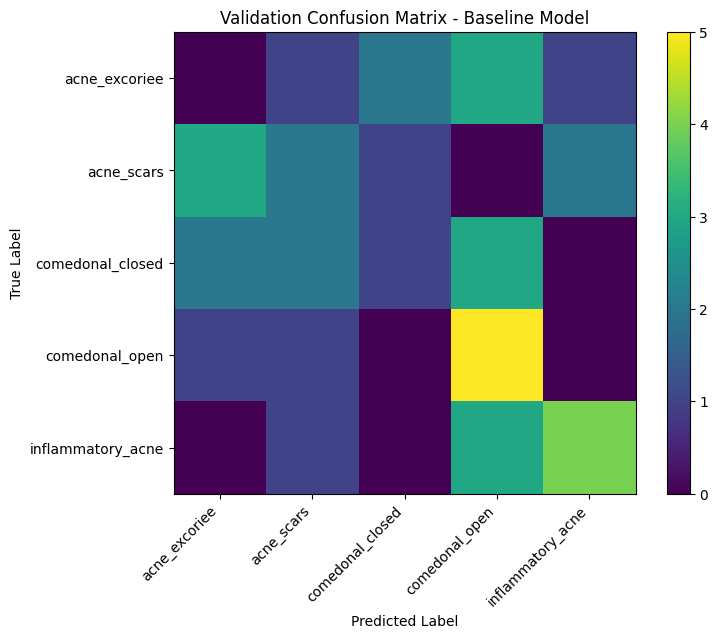

In [10]:
cm = confusion_matrix(y_val_encoded, val_predictions)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Validation Confusion Matrix - Baseline Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45, ha="right")
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.colorbar()
plt.show()